In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.signal as scisig

In [12]:
freqs = [45, 46, 47, 48, 52, 53, 54, 55]
phs = np.zeros((len(freqs), 10))
for n, freq in enumerate(freqs):
    filename = 'E://lorentz_force//sphere20250507//20250522//Freq sweep//' 
    filename = filename + str(freq) + '.mat'
    data = sio.loadmat(filename)
    tt = np.transpose(data['D'])[0]
    Tint = data['Tinterval'][0][0]
    ph = np.zeros(10)
    for i in range(10):
        PSD = scisig.welch(tt[i*10**6:(i+1)*10**6], fs = 1/Tint, nperseg = int(1/Tint))
        ph[i] = PSD[1][freq*1000]
    phs[n] = ph

In [17]:
ph_m = np.zeros(len(freqs))
for n, ph in enumerate(phs):
    ph_m[n] = np.mean(ph)

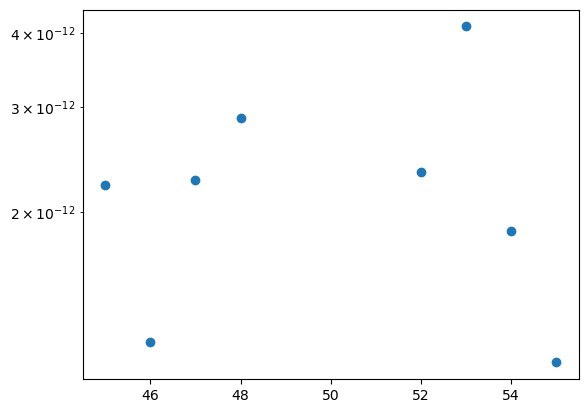

In [26]:
plt.plot(freqs, np.sqrt(ph_m*10**(-15)), 'o')
plt.yscale('log')

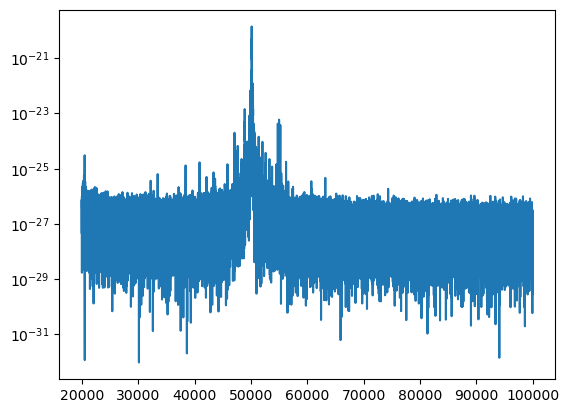

In [24]:
plt.plot(PSD[0][20000:100000], PSD[1][20000:100000]*10**(-15))
plt.yscale('log')